In [22]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

import random
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

In [23]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

env = gym.make("MountainCar-v0")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("State dimension:", state_dim)
print("Number of actions:", action_dim)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

State dimension: 2
Number of actions: 3
Device: cpu


In [24]:
state_low = env.observation_space.low
state_high = env.observation_space.high


def normalize_state(state):

    state = np.asarray(state, dtype=np.float32)

    normalized = 2.0 * (
        (state - state_low)
        / (state_high - state_low)
    ) - 1.0

    return normalized.astype(np.float32)

In [25]:
class DQN(nn.Module):

    def __init__(self, state_dim, action_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(state_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_dim)
        )

    def forward(self, x):

        return self.network(x)

In [26]:
policy_net = DQN(
    state_dim,
    action_dim
).to(device)

target_net = DQN(
    state_dim,
    action_dim
).to(device)


target_net.load_state_dict(
    policy_net.state_dict()
)

target_net.eval()

DQN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [27]:
class ReplayBuffer:

    def __init__(self, capacity):

        self.buffer = deque(
            maxlen=capacity
        )

    def push(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )

    def sample(self, batch_size):

        batch = random.sample(
            self.buffer,
            batch_size
        )

        states, actions, rewards, \
        next_states, dones = zip(*batch)

        states = torch.tensor(
            np.array(states),
            dtype=torch.float32,
            device=device
        )

        actions = torch.tensor(
            actions,
            dtype=torch.int64,
            device=device
        )

        rewards = torch.tensor(
            rewards,
            dtype=torch.float32,
            device=device
        )

        next_states = torch.tensor(
            np.array(next_states),
            dtype=torch.float32,
            device=device
        )

        dones = torch.tensor(
            dones,
            dtype=torch.float32,
            device=device
        )

        return (
            states,
            actions,
            rewards,
            next_states,
            dones
        )

    def __len__(self):

        return len(self.buffer)

In [28]:
replay_buffer = ReplayBuffer(
    capacity=100_000
)

In [29]:
NUM_EPISODES = 1200

GAMMA = 0.99

LEARNING_RATE = 1e-3

BATCH_SIZE = 64

MIN_REPLAY_SIZE = 2000

TARGET_UPDATE_STEPS = 1000


EPSILON_START = 1.0

EPSILON_END = 0.05

EPSILON_DECAY_STEPS = 80_000

In [30]:
optimizer = optim.Adam(
    policy_net.parameters(),
    lr=LEARNING_RATE
)

In [31]:
def get_epsilon(step):

    fraction = min(
        step / EPSILON_DECAY_STEPS,
        1.0
    )

    epsilon = (
        EPSILON_START
        +
        fraction
        * (
            EPSILON_END
            - EPSILON_START
        )
    )

    return epsilon

In [32]:
def select_action(state, epsilon):

    if np.random.random() < epsilon:

        return env.action_space.sample()

    state_normalized = normalize_state(
        state
    )

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)

    with torch.no_grad():

        q_values = policy_net(
            state_tensor
        )

    action = torch.argmax(
        q_values,
        dim=1
    ).item()

    return action

In [33]:
USE_REWARD_SHAPING = False


def potential(state):

    velocity = state[1]

    normalized_speed = (
        abs(velocity) / 0.07
    )

    return 50.0 * normalized_speed

In [34]:
def get_training_reward(
    state,
    next_state,
    reward,
    done
):

    if not USE_REWARD_SHAPING:

        return reward

    current_potential = potential(
        state
    )

    if done:

        next_potential = 0.0

    else:

        next_potential = potential(
            next_state
        )

    shaped_reward = (
        reward
        +
        GAMMA * next_potential
        -
        current_potential
    )

    return shaped_reward

In [35]:
def train_step():

    if len(replay_buffer) < MIN_REPLAY_SIZE:

        return None

    (
        states,
        actions,
        rewards,
        next_states,
        dones
    ) = replay_buffer.sample(
        BATCH_SIZE
    )


    # Current Q(s,a)

    q_values = policy_net(states)

    current_q = q_values.gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)


    # Target Q-value

    with torch.no_grad():

        next_q_values = target_net(
            next_states
        )

        max_next_q = next_q_values.max(
            dim=1
        ).values

        target_q = (
            rewards
            +
            GAMMA
            * max_next_q
            * (1.0 - dones)
        )


    # Loss

    loss = nn.functional.smooth_l1_loss(
        current_q,
        target_q
    )


    # Gradient descent

    optimizer.zero_grad()

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        policy_net.parameters(),
        max_norm=10.0
    )

    optimizer.step()

    return loss.item()

In [36]:
episode_rewards = []

episode_lengths = []

success_history = []

loss_history = []


global_step = 0


for episode in range(NUM_EPISODES):

    state, info = env.reset()

    episode_reward = 0

    terminated = False
    truncated = False


    while not (
        terminated or truncated
    ):

        epsilon = get_epsilon(
            global_step
        )


        # Choose action

        action = select_action(
            state,
            epsilon
        )


        # Environment step

        (
            next_state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)


        done = (
            terminated or truncated
        )


        # Reward used by DQN

        training_reward = \
            get_training_reward(
                state,
                next_state,
                reward,
                done
            )


        # Store transition

        replay_buffer.push(
            normalize_state(state),
            action,
            training_reward,
            normalize_state(next_state),
            done
        )


        # Train network

        loss = train_step()

        if loss is not None:

            loss_history.append(loss)


        # Update target network

        if (
            global_step
            % TARGET_UPDATE_STEPS
            == 0
        ):

            target_net.load_state_dict(
                policy_net.state_dict()
            )


        state = next_state

        episode_reward += reward

        global_step += 1


    episode_rewards.append(
        episode_reward
    )

    episode_lengths.append(
        -episode_reward
    )

    success_history.append(
        int(terminated)
    )


    if (episode + 1) % 50 == 0:

        average_reward = np.mean(
            episode_rewards[-100:]
        )

        success_rate = np.mean(
            success_history[-100:]
        )

        print(
            f"Episode {episode + 1:4d} | "
            f"Average reward: "
            f"{average_reward:7.2f} | "
            f"Success rate: "
            f"{100 * success_rate:6.2f}% | "
            f"Epsilon: "
            f"{epsilon:.3f}"
        )

Episode   50 | Average reward: -200.00 | Success rate:   0.00% | Epsilon: 0.881
Episode  100 | Average reward: -200.00 | Success rate:   0.00% | Epsilon: 0.763
Episode  150 | Average reward: -200.00 | Success rate:   0.00% | Epsilon: 0.644
Episode  200 | Average reward: -200.00 | Success rate:   0.00% | Epsilon: 0.525
Episode  250 | Average reward: -196.89 | Success rate:  13.00% | Epsilon: 0.410
Episode  300 | Average reward: -181.79 | Success rate:  52.00% | Epsilon: 0.309
Episode  350 | Average reward: -165.69 | Success rate:  83.00% | Epsilon: 0.213
Episode  400 | Average reward: -173.29 | Success rate:  63.00% | Epsilon: 0.103
Episode  450 | Average reward: -174.53 | Success rate:  47.00% | Epsilon: 0.050
Episode  500 | Average reward: -145.71 | Success rate:  77.00% | Epsilon: 0.050
Episode  550 | Average reward: -128.64 | Success rate:  99.00% | Epsilon: 0.050
Episode  600 | Average reward: -134.52 | Success rate:  99.00% | Epsilon: 0.050
Episode  650 | Average reward: -158.14 |

In [44]:
from utils import alert_training_complete

alert_training_complete()

Training finished.


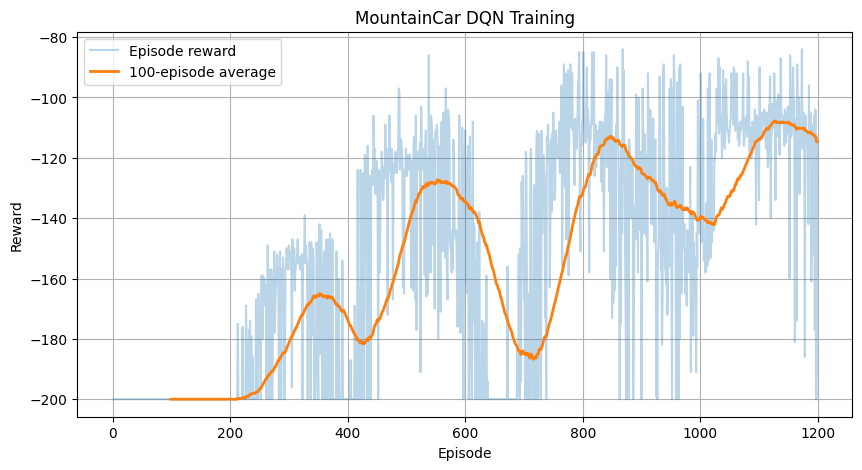

In [37]:
window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)


plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards,
    alpha=0.3,
    label="Episode reward"
)

plt.plot(
    np.arange(
        window - 1,
        len(episode_rewards)
    ),
    moving_average,
    linewidth=2,
    label="100-episode average"
)

plt.xlabel("Episode")

plt.ylabel("Reward")

plt.title(
    "MountainCar DQN Training"
)

plt.legend()

plt.grid()

plt.show()

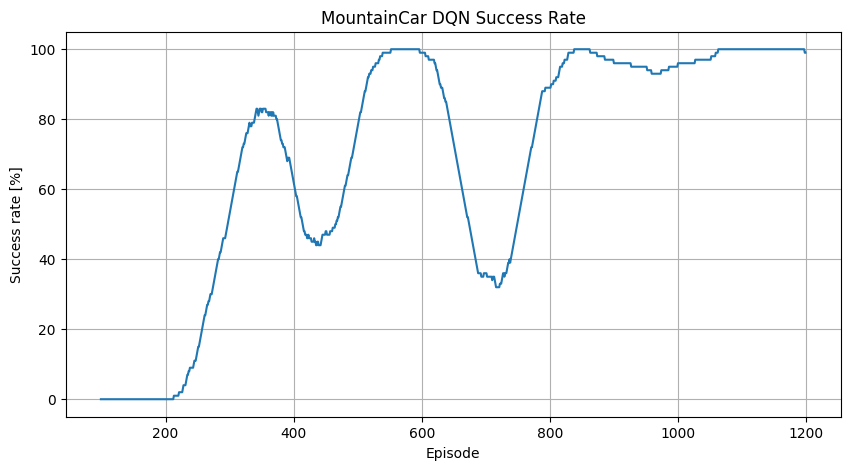

In [38]:
success_average = np.convolve(
    success_history,
    np.ones(window) / window,
    mode="valid"
)


plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(
        window - 1,
        len(success_history)
    ),
    100 * success_average
)

plt.xlabel("Episode")

plt.ylabel("Success rate [%]")

plt.title(
    "MountainCar DQN Success Rate"
)

plt.grid()

plt.show()

In [39]:
checkpoint = {

    "model_state_dict":
        policy_net.state_dict(),

    "target_state_dict":
        target_net.state_dict(),

    "optimizer_state_dict":
        optimizer.state_dict(),

    "episodes":
        NUM_EPISODES,

    "gamma":
        GAMMA,

    "learning_rate":
        LEARNING_RATE,

    "epsilon_start":
        EPSILON_START,

    "epsilon_end":
        EPSILON_END,

    "epsilon_decay_steps":
        EPSILON_DECAY_STEPS,

    "state_low":
        state_low,

    "state_high":
        state_high,

    "reward_shaping":
        USE_REWARD_SHAPING
}

from pathlib import Path

model_path = Path("models") / "mountaincar_dqn_no_reward_shaping.pth"
model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save(
    checkpoint,
    model_path
)

print(
    f"Model saved to {model_path}"
)

Model saved to models\mountaincar_dqn_no_reward_shaping.pth


In [40]:
num_test_episodes = 100

test_successes = 0

test_episode_lengths = []


for episode in range(
    num_test_episodes
):

    state, info = env.reset()

    terminated = False

    truncated = False

    steps = 0


    while not (
        terminated or truncated
    ):

        state_normalized = \
            normalize_state(state)

        state_tensor = torch.tensor(
            state_normalized,
            dtype=torch.float32,
            device=device
        ).unsqueeze(0)


        # Pure exploitation

        with torch.no_grad():

            q_values = policy_net(
                state_tensor
            )

            action = torch.argmax(
                q_values,
                dim=1
            ).item()


        (
            next_state,
            reward,
            terminated,
            truncated,
            info
        ) = env.step(action)


        state = next_state

        steps += 1


    if terminated:

        test_successes += 1

    test_episode_lengths.append(
        steps
    )


print(
    "Successful episodes:",
    test_successes,
    "/",
    num_test_episodes
)

print(
    "Success rate:",
    f"{100 * test_successes / num_test_episodes:.2f}%"
)

print(
    "Average episode length:",
    f"{np.mean(test_episode_lengths):.2f} steps"
)

Successful episodes: 98 / 100
Success rate: 98.00%
Average episode length: 112.69 steps


In [41]:
env.close()

render_env = gym.make(
    "MountainCar-v0",
    render_mode="human"
)


state, info = render_env.reset()

terminated = False

truncated = False

steps = 0


while not (
    terminated or truncated
):

    state_normalized = \
        normalize_state(state)

    state_tensor = torch.tensor(
        state_normalized,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0)


    with torch.no_grad():

        q_values = policy_net(
            state_tensor
        )

        action = torch.argmax(
            q_values,
            dim=1
        ).item()


    (
        state,
        reward,
        terminated,
        truncated,
        info
    ) = render_env.step(action)

    steps += 1


render_env.close()

print(
    f"Episode completed in {steps} steps"
)

Episode completed in 115 steps
